In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("julian3833/jigsaw-toxic-comment-classification-challenge")

print("Path to dataset files:", path)

100%|██████████| 53.4M/53.4M [00:02<00:00, 19.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/versions/1


📂 Looking for files in: /root/.cache/kagglehub/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/versions/1
Files found: ['train.csv', 'test.csv', 'test_labels.csv', 'sample_submission.csv']
✅ Found training file: /root/.cache/kagglehub/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/versions/1/train.csv

Dataset Shape: (159571, 8)
Column Names: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Sample Data:


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0



Missing values:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


/tmp/ipython-input-2835349012.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


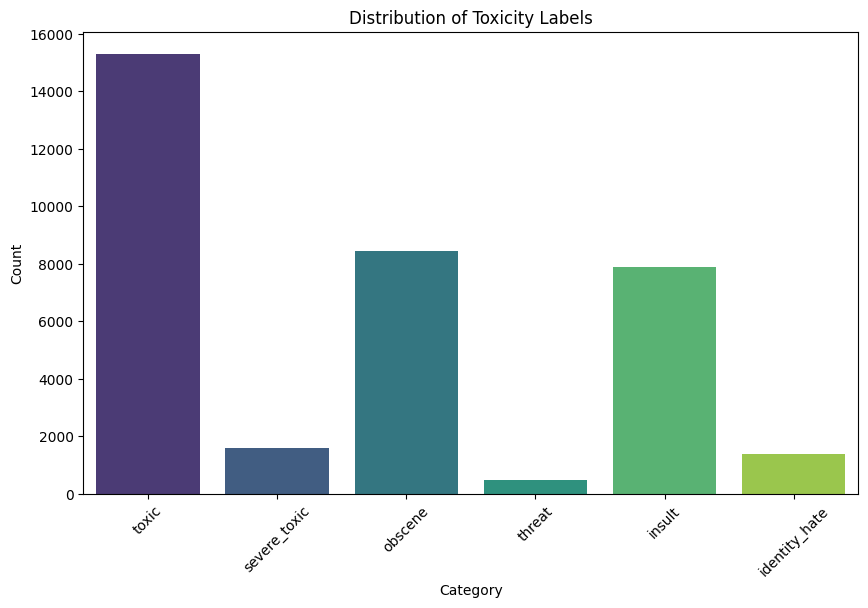


--- Class Imbalance Summary ---
Total Comments: 159571
Clean (Safe) Comments: 143346 (89.83%)
Toxic (Unsafe) Comments: 16225 (10.17%)


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. LOCATE THE DATA
# ---------------------------------------------------------
# 'path' is the variable from your previous step (kagglehub download)
print(f"📂 Looking for files in: {path}")

# List all files in the directory to see filenames
files = os.listdir(path)
print("Files found:", files)

# Construct the full path to train.csv
# We search for the file that starts with 'train' to be safe
train_filename = next((f for f in files if 'train' in f and f.endswith('.csv')), None)

if train_filename:
    full_path = os.path.join(path, train_filename)
    print(f"✅ Found training file: {full_path}")

    # ---------------------------------------------------------
    # 2. LOAD DATASET
    # ---------------------------------------------------------
    df = pd.read_csv(full_path)

    # Display structure
    print(f"\nDataset Shape: {df.shape}")
    print("Column Names:", df.columns.tolist())

    # Show first 5 rows
    print("\nSample Data:")
    display(df.head())

    # ---------------------------------------------------------
    # 3. EXPLORATORY DATA ANALYSIS (EDA)
    # ---------------------------------------------------------
    # Define label columns
    label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

    # Check for missing values
    print(f"\nMissing values:\n{df.isnull().sum()}")

    # Calculate counts for each toxicity category
    label_counts = df[label_cols].sum()

    # Plot the distribution
    plt.figure(figsize=(10, 6))
    sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
    plt.title('Distribution of Toxicity Labels')
    plt.xlabel('Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

    # Analyze Class Imbalance (Clean vs Toxic)
    # A comment is "Clean" if all label columns are 0
    row_sums = df[label_cols].sum(axis=1)
    df['clean'] = (row_sums == 0).astype(int)

    clean_count = df['clean'].sum()
    toxic_count = len(df) - clean_count

    print(f"\n--- Class Imbalance Summary ---")
    print(f"Total Comments: {len(df)}")
    print(f"Clean (Safe) Comments: {clean_count} ({(clean_count/len(df))*100:.2f}%)")
    print(f"Toxic (Unsafe) Comments: {toxic_count} ({(toxic_count/len(df))*100:.2f}%)")

else:
    print("❌ Error: Could not find 'train.csv' in the downloaded folder.")
    print("Please check the 'Files found' list above. You might need to unzip a file first.")

In [3]:
import re
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# 1. Download NLTK resources
# These are dictionaries for stopwords and word roots
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Check if text is a string (handles potential NaN values)
    if not isinstance(text, str):
        return ""

    # 1. Convert to Lowercase
    # Why: "Toxic" and "toxic" should be treated as the same feature.
    text = text.lower()

    # 2. Remove URLs and HTML Tags
    # Why: These are technical artifacts, not human language content.
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)

    # 3. Remove Mentions (@User) and Hashtags (#Topic)
    # Why: Usernames are privacy-sensitive and specific to individuals, not the toxicity class.
    text = re.sub(r'@\w+|#\w+', '', text)

    # 4. Handle Emojis and Slang (Basic Clean)
    # For this model, we remove non-ASCII characters (emojis) to keep the vocabulary standard.
    text = text.encode('ascii', 'ignore').decode('ascii')

    # 5. Remove Punctuation and Numbers
    # Why: We want to focus on words. "Kill!!" should be the same as "Kill".
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    # 6. Stopword Removal & Lemmatization
    # Why: Reduces vocabulary size. "running" -> "run", "better" -> "good".
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return " ".join(tokens)

# --- Apply the cleaning ---
print("⏳ Processing text... (This may take 1-2 minutes)")
df['cleaned_text'] = df['comment_text'].apply(preprocess_text)

# --- Verification ---
# Let's see the before-and-after difference
print("\nTransformation Example:")
print("-" * 50)
sample_row = df[df['toxic'] == 1].iloc[0] # Pick a toxic comment to see changes
print(f"Original: {sample_row['comment_text']}")
print(f"Cleaned:  {sample_row['cleaned_text']}")
print("-" * 50)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


⏳ Processing text... (This may take 1-2 minutes)

Transformation Example:
--------------------------------------------------
Original: COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK
Cleaned:  cocksucker piss around work
--------------------------------------------------


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer
from sklearn.model_selection import train_test_split

# --- Hyperparameters ---
MAX_LEN = 128            # Maximum number of tokens per comment
TRAIN_BATCH_SIZE = 16    # Batch size for training
VALID_BATCH_SIZE = 16    # Batch size for validation
EPOCHS = 2               # Number of training epochs
LEARNING_RATE = 1e-05    # Learning rate

# --- 1. Initialize Tokenizer ---
# We use the 'uncased' version to match our lowercased text
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# --- 2. Create Custom Dataset Class ---
class ToxicityDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.data = dataframe
        self.text = dataframe.cleaned_text
        self.targets = dataframe[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].values
        self.max_len = max_len

    def __len__(self):
        return len(self.text)

    def __getitem__(self, index):
        text = str(self.text.iloc[index])
        text = " ".join(text.split())

        # Encoding process
        inputs = self.tokenizer.encode_plus(
            text,
            None,
            add_special_tokens=True, # Add [CLS] and [SEP]
            max_length=self.max_len,
            padding='max_length',    # Pad to max_length
            truncation=True,         # Truncate if longer than max_length
            return_token_type_ids=True
        )

        return {
            'ids': torch.tensor(inputs['input_ids'], dtype=torch.long),
            'mask': torch.tensor(inputs['attention_mask'], dtype=torch.long),
            'targets': torch.tensor(self.targets[index], dtype=torch.float)
        }

# --- 3. Split Data ---
# 80% Training, 20% Validation
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Training Samples: {len(train_df)}")
print(f"Validation Samples: {len(val_df)}")

# --- 4. Load Data into PyTorch Loaders ---
print("🔄 Preparing DataLoaders...")
training_set = ToxicityDataset(train_df, tokenizer, MAX_LEN)
validation_set = ToxicityDataset(val_df, tokenizer, MAX_LEN)

train_params = {'batch_size': TRAIN_BATCH_SIZE, 'shuffle': True, 'num_workers': 0}
val_params = {'batch_size': VALID_BATCH_SIZE, 'shuffle': False, 'num_workers': 0}

training_loader = DataLoader(training_set, **train_params)
validation_loader = DataLoader(validation_set, **val_params)

print("✅ DataLoaders Ready. Next Step: Model Architecture.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Training Samples: 127656
Validation Samples: 31915
🔄 Preparing DataLoaders...
✅ DataLoaders Ready. Next Step: Model Architecture.


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer
from sklearn.model_selection import train_test_split

# --- Hyperparameters ---
MAX_LEN = 128            # Maximum number of tokens per comment
TRAIN_BATCH_SIZE = 16    # Batch size for training
VALID_BATCH_SIZE = 16    # Batch size for validation
EPOCHS = 2               # Number of training epochs
LEARNING_RATE = 1e-05    # Learning rate

# --- 1. Initialize Tokenizer ---
# We use the 'uncased' version to match our lowercased text
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# --- 2. Create Custom Dataset Class ---
class ToxicityDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.data = dataframe
        self.text = dataframe.cleaned_text
        self.targets = dataframe[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].values
        self.max_len = max_len

    def __len__(self):
        return len(self.text)

    def __getitem__(self, index):
        text = str(self.text.iloc[index])
        text = " ".join(text.split())

        # Encoding process
        inputs = self.tokenizer.encode_plus(
            text,
            None,
            add_special_tokens=True, # Add [CLS] and [SEP]
            max_length=self.max_len,
            padding='max_length',    # Pad to max_length
            truncation=True,         # Truncate if longer than max_length
            return_token_type_ids=True
        )

        return {
            'ids': torch.tensor(inputs['input_ids'], dtype=torch.long),
            'mask': torch.tensor(inputs['attention_mask'], dtype=torch.long),
            'targets': torch.tensor(self.targets[index], dtype=torch.float)
        }

# --- 3. Split Data ---
# 80% Training, 20% Validation
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Training Samples: {len(train_df)}")
print(f"Validation Samples: {len(val_df)}")

# --- 4. Load Data into PyTorch Loaders ---
print("🔄 Preparing DataLoaders...")
training_set = ToxicityDataset(train_df, tokenizer, MAX_LEN)
validation_set = ToxicityDataset(val_df, tokenizer, MAX_LEN)

train_params = {'batch_size': TRAIN_BATCH_SIZE, 'shuffle': True, 'num_workers': 0}
val_params = {'batch_size': VALID_BATCH_SIZE, 'shuffle': False, 'num_workers': 0}

training_loader = DataLoader(training_set, **train_params)
validation_loader = DataLoader(validation_set, **val_params)

print("✅ DataLoaders Ready. Next Step: Model Architecture.")

Training Samples: 127656
Validation Samples: 31915
🔄 Preparing DataLoaders...
✅ DataLoaders Ready. Next Step: Model Architecture.


In [6]:
import torch
import torch.nn as nn
from transformers import DistilBertModel

# 1. Setup Device (GPU is highly recommended)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🚀 Computation Device: {device}")

# 2. Define the Neural Network Class
class DistilBERTClass(torch.nn.Module):
    def __init__(self):
        super(DistilBERTClass, self).__init__()
        # Load the pre-trained DistilBERT model
        self.l1 = DistilBertModel.from_pretrained("distilbert-base-uncased")

        # Add a dense layer for classification
        # 768 is the standard output dimension of DistilBERT
        self.pre_classifier = torch.nn.Linear(768, 768)
        self.dropout = torch.nn.Dropout(0.3)

        # Output layer: 6 neurons for our 6 labels
        self.classifier = torch.nn.Linear(768, 6)

    def forward(self, input_ids, attention_mask):
        # Pass inputs through DistilBERT
        output_1 = self.l1(input_ids=input_ids, attention_mask=attention_mask)

        # hidden_state is a tensor of shape (batch_size, sequence_length, hidden_size)
        hidden_state = output_1[0]

        # We only care about the first token [CLS] which represents the whole sentence context
        pooler = hidden_state[:, 0]

        # Pass through classification layers
        pooler = self.pre_classifier(pooler)
        pooler = torch.nn.ReLU()(pooler)
        pooler = self.dropout(pooler)
        output = self.classifier(pooler)

        return output

# 3. Initialize and Move to Device
model = DistilBERTClass()
model.to(device)

print("✅ Model Architecture Created and Loaded to GPU.")

🚀 Computation Device: cuda


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

✅ Model Architecture Created and Loaded to GPU.


🔥 Starting Training... (This will take approx 15-20 mins on GPU)
Epoch 1 Started...
   Batch 500, Loss: 0.0517, Time: 87.11s
   Batch 1000, Loss: 0.0604, Time: 176.70s
   Batch 1500, Loss: 0.0454, Time: 265.31s
   Batch 2000, Loss: 0.0398, Time: 353.02s
   Batch 2500, Loss: 0.0138, Time: 440.90s
   Batch 3000, Loss: 0.0362, Time: 528.74s
   Batch 3500, Loss: 0.0482, Time: 616.57s
   Batch 4000, Loss: 0.0428, Time: 704.33s
   Batch 4500, Loss: 0.0632, Time: 792.30s
   Batch 5000, Loss: 0.0296, Time: 880.26s
   Batch 5500, Loss: 0.0064, Time: 968.08s
   Batch 6000, Loss: 0.0202, Time: 1056.05s
   Batch 6500, Loss: 0.0769, Time: 1143.78s
   Batch 7000, Loss: 0.0930, Time: 1231.46s
   Batch 7500, Loss: 0.0381, Time: 1319.29s
✅ Epoch 1 Completed. Average Loss: 0.0547
Epoch 2 Started...
   Batch 500, Loss: 0.0329, Time: 87.88s
   Batch 1000, Loss: 0.0375, Time: 175.55s
   Batch 1500, Loss: 0.0082, Time: 263.31s
   Batch 2000, Loss: 0.0149, Time: 351.11s
   Batch 2500, Loss: 0.0502, Time: 438

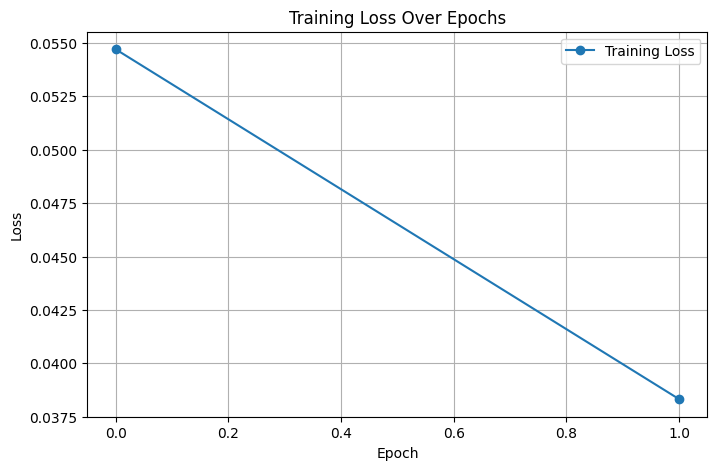

In [7]:
import time

# 1. Define Loss Function and Optimizer
# BCEWithLogitsLoss includes the Sigmoid activation implicitly
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=LEARNING_RATE)

def train(epoch):
    model.train()
    running_loss = 0
    start_time = time.time()

    print(f"Epoch {epoch+1} Started...")

    for i, data in enumerate(training_loader, 0):
        # Move batch to GPU
        ids = data['ids'].to(device, dtype=torch.long)
        mask = data['mask'].to(device, dtype=torch.long)
        targets = data['targets'].to(device, dtype=torch.float)

        # Forward Pass
        outputs = model(ids, mask)

        # Calculate Loss
        loss = loss_fn(outputs, targets)

        # Backward Pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Print status every 500 batches
        if i % 500 == 0 and i > 0:
            elapsed = time.time() - start_time
            print(f'   Batch {i}, Loss: {loss.item():.4f}, Time: {elapsed:.2f}s')

    avg_loss = running_loss / len(training_loader)
    return avg_loss

# 2. Execute Training Loop
train_losses = []

print("🔥 Starting Training... (This will take approx 15-20 mins on GPU)")

for epoch in range(EPOCHS):
    avg_loss = train(epoch)
    train_losses.append(avg_loss)
    print(f"✅ Epoch {epoch+1} Completed. Average Loss: {avg_loss:.4f}")

# 3. Visualize Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker='o', label='Training Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

In [8]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, multilabel_confusion_matrix
import numpy as np

def validation():
    model.eval()
    fin_targets = []
    fin_outputs = []
    with torch.no_grad():
        for _, data in enumerate(validation_loader, 0):
            ids = data['ids'].to(device, dtype=torch.long)
            mask = data['mask'].to(device, dtype=torch.long)
            targets = data['targets'].to(device, dtype=torch.float)

            outputs = model(ids, mask)

            # Apply Sigmoid to get probabilities (0 to 1)
            fin_targets.extend(targets.cpu().detach().numpy().tolist())
            fin_outputs.extend(torch.sigmoid(outputs).cpu().detach().numpy().tolist())

    return fin_outputs, fin_targets

print("📊 Validating Performance...")
outputs, targets = validation()

# Convert probabilities to binary predictions (Threshold = 0.5)
outputs_bin = np.array(outputs) >= 0.5
targets_bin = np.array(targets)

# Calculate Metrics
accuracy = accuracy_score(targets_bin, outputs_bin)
f1_micro = f1_score(targets_bin, outputs_bin, average='micro')

print(f"\nValidation Accuracy: {accuracy:.4f}")
print(f"F1 Score (Micro): {f1_micro:.4f}")

print("\n" + "="*60)
print("Detailed Classification Report")
print("="*60)
label_names = ['Toxic', 'Severe Toxic', 'Obscene', 'Threat', 'Insult', 'Identity Hate']
print(classification_report(targets_bin, outputs_bin, target_names=label_names, zero_division=0))

📊 Validating Performance...

Validation Accuracy: 0.9246
F1 Score (Micro): 0.7641

Detailed Classification Report
               precision    recall  f1-score   support

        Toxic       0.89      0.72      0.80      3056
 Severe Toxic       0.69      0.18      0.28       321
      Obscene       0.85      0.82      0.84      1715
       Threat       0.75      0.08      0.15        74
       Insult       0.74      0.75      0.75      1614
Identity Hate       0.78      0.33      0.47       294

    micro avg       0.83      0.71      0.76      7074
    macro avg       0.78      0.48      0.55      7074
 weighted avg       0.83      0.71      0.75      7074
  samples avg       0.06      0.06      0.06      7074



In [9]:
def predict_cyberbullying(text):
    model.eval()

    # 1. Preprocess the input text (using the function from Step 2)
    clean_text = preprocess_text(text)

    # 2. Tokenize
    inputs = tokenizer.encode_plus(
        clean_text,
        None,
        add_special_tokens=True,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_token_type_ids=True
    )

    ids = torch.tensor(inputs['input_ids'], dtype=torch.long).unsqueeze(0).to(device)
    mask = torch.tensor(inputs['attention_mask'], dtype=torch.long).unsqueeze(0).to(device)

    # 3. Predict
    with torch.no_grad():
        output = model(ids, mask)
        prob = torch.sigmoid(output)

    # 4. Display Results
    probs_np = prob.cpu().detach().numpy()[0]

    print(f"\n💬 Input: '{text}'")
    print("-" * 40)

    is_safe = True
    for i, score in enumerate(probs_np):
        label = label_names[i]
        # Check if confidence is above 50%
        if score > 0.5:
            print(f"🔴 DETECTED: {label:<15} (Confidence: {score:.4f})")
            is_safe = False

    if is_safe:
        print("🟢 RESULT: Safe / Non-Toxic")

# --- TRY YOUR OWN EXAMPLES ---
predict_cyberbullying("You are amazing and I love your work!")
predict_cyberbullying("You are so stupid, just get off the internet.")
predict_cyberbullying("I will kill you.")


💬 Input: 'You are amazing and I love your work!'
----------------------------------------
🟢 RESULT: Safe / Non-Toxic

💬 Input: 'You are so stupid, just get off the internet.'
----------------------------------------
🔴 DETECTED: Toxic           (Confidence: 0.9162)
🔴 DETECTED: Insult          (Confidence: 0.5217)

💬 Input: 'I will kill you.'
----------------------------------------
🔴 DETECTED: Toxic           (Confidence: 0.6240)


/tmp/ipython-input-3549353667.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='magma')


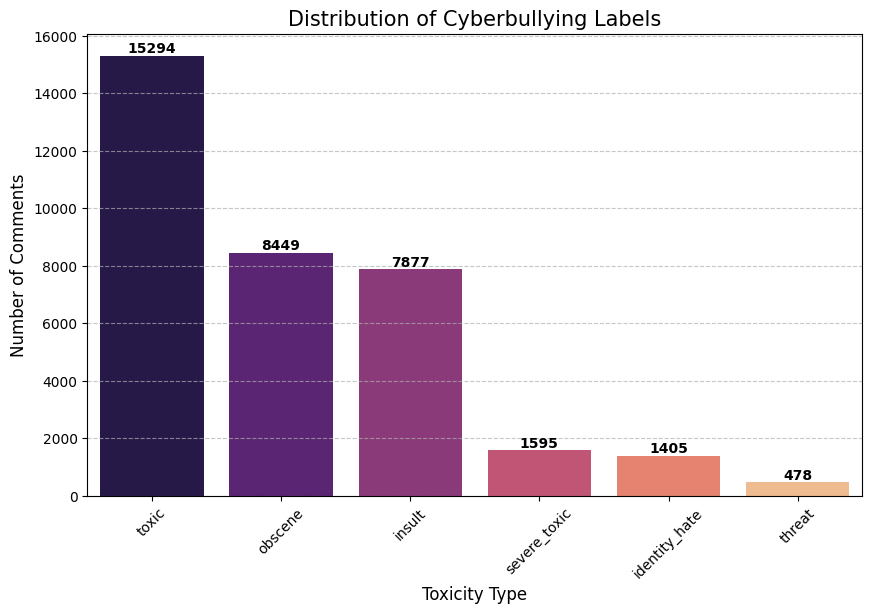

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure you have your dataframe 'df' loaded
# label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

plt.figure(figsize=(10, 6))
# Calculate sums for each column
label_counts = df[label_cols].sum().sort_values(ascending=False)

# Create Bar Plot
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='magma')

# Add values on top of bars
for i, v in enumerate(label_counts.values):
    ax.text(i, v + 100, str(v), color='black', ha='center', fontweight='bold')

plt.title('Distribution of Cyberbullying Labels', fontsize=15)
plt.ylabel('Number of Comments', fontsize=12)
plt.xlabel('Toxicity Type', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

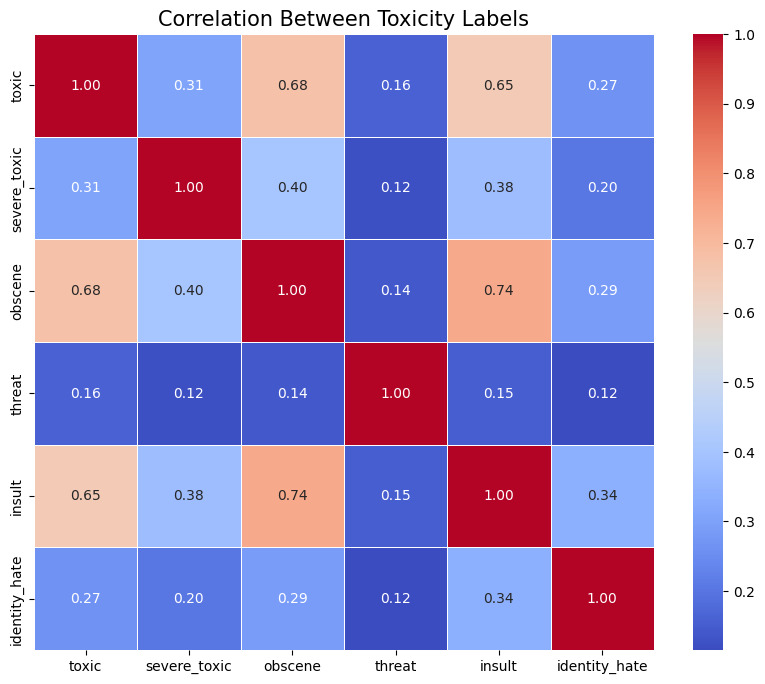

In [12]:
plt.figure(figsize=(10, 8))
# Calculate correlation matrix
corr_matrix = df[label_cols].corr()

# Create Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Between Toxicity Labels', fontsize=15)
plt.show()

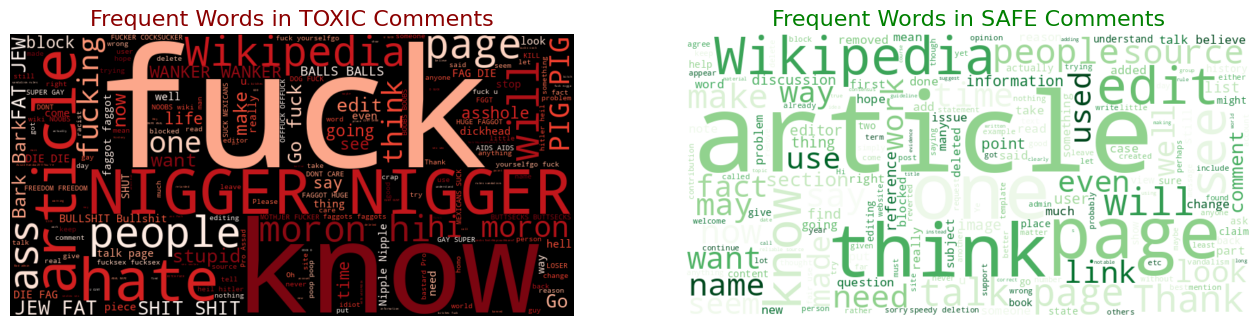

In [13]:
from wordcloud import WordCloud

# 1. Filter Toxic vs Safe comments
toxic_text = " ".join(df[df['toxic'] == 1]['comment_text'].values)
safe_text = " ".join(df[df['clean'] == 1]['comment_text'].values)

# 2. Generate Word Clouds
wc_toxic = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(toxic_text)
wc_safe = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(safe_text)

# 3. Plot them side by side
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wc_toxic, interpolation='bilinear')
plt.title('Frequent Words in TOXIC Comments', fontsize=16, color='darkred')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wc_safe, interpolation='bilinear')
plt.title('Frequent Words in SAFE Comments', fontsize=16, color='green')
plt.axis('off')

plt.show()

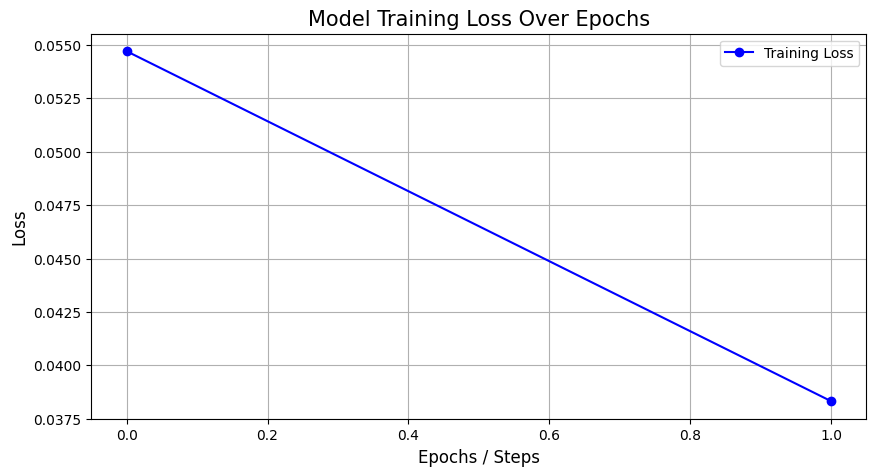

In [14]:
# Assuming 'train_losses' is the list you created during the training loop
# Example: train_losses = [0.45, 0.32, 0.21, 0.15]

plt.figure(figsize=(10, 5))
plt.plot(train_losses, marker='o', linestyle='-', color='b', label='Training Loss')

plt.title('Model Training Loss Over Epochs', fontsize=15)
plt.xlabel('Epochs / Steps', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()